# List all available drives
!ls /content/drive/

# List contents of your shared drive
!ls "/content/drive/Shareddrives/Group E: Shared/"

# Load dataset from group shared drive
import pandas as pd
df = pd.read_csv('/content/drive/Shareddrives/Group E: Shared/airbnb_nyc_preprocessed_with_groups.csv')
print(df.head())


In [ ]:
# Mount Google Drive into Colab
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# List all available drives
!ls /content/drive/


MyDrive


In [ ]:
# Explore inside MyDrive
!ls "/content/drive/MyDrive/"


 AB_NYC_2019.csv  'Colab Notebooks'


In [ ]:
# Load dataset and import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/AB_NYC_2019.csv')
print(df.head())


     id                                              name  host_id  \
0  2539                Clean & quiet apt home by the park     2787   
1  2595                             Skylit Midtown Castle     2845   
2  3647               THE VILLAGE OF HARLEM....NEW YORK !     4632   
3  3831                   Cozy Entire Floor of Brownstone     4869   
4  5022  Entire Apt: Spacious Studio/Loft by central park     7192   

     host_name neighbourhood_group neighbourhood  latitude  longitude  \
0         John            Brooklyn    Kensington  40.64749  -73.97237   
1     Jennifer           Manhattan       Midtown  40.75362  -73.98377   
2    Elisabeth           Manhattan        Harlem  40.80902  -73.94190   
3  LisaRoxanne            Brooklyn  Clinton Hill  40.68514  -73.95976   
4        Laura           Manhattan   East Harlem  40.79851  -73.94399   

         room_type  price  minimum_nights  number_of_reviews last_review  \
0     Private room    149               1                  9  20

In [ ]:
# Install required packages
!pip install torch torchvision torchaudio nltk pandas scikit-learn


In [ ]:
# Import libraries
import nltk
nltk.download('vader_lexicon')
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import re


[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [ ]:
# Check the number of nulls in each field
df.isnull().sum()
print(df.isnull().sum())


id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64


In [ ]:
# Recheck the number of nulls in each field
df = df[pd.notnull(df['name'])]
df = df[pd.notnull(df['host_name'])]


In [ ]:
# Recheck the number of nulls in each field
df.isnull().sum()
print(df.isnull().sum())


id                                    0
name                                  0
host_id                               0
host_name                             0
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10037
reviews_per_month                 10037
calculated_host_listings_count        0
availability_365                      0
dtype: int64


In [ ]:
# Create combined text field
df = df[['name','host_name','neighbourhood','neighbourhood_group']].fillna("")
df['combined_text'] = df.apply(lambda x: ' '.join(x), axis=1)


In [ ]:
# Creating a Lexicon-based sentiment labels
from nltk.sentiment import SentimentIntensityAnalyzer
sia = SentimentIntensityAnalyzer()
df['label'] = df['combined_text'].apply(lambda x: 1 if sia.polarity_scores(x)['compound'] > 0 else 0)


In [ ]:
# Tokenization and vocabulary creation
def basic_tokenizer(text):
    return re.findall(r"\b\w+\b", text.lower())


In [ ]:
# Build vocabulary for the model
all_tokens = []
for text in df['combined_text']:
    all_tokens.extend(basic_tokenizer(text))
vocab = {tok: idx+1 for idx, tok in enumerate(set(all_tokens))}
unk_index = 0  # reserve 0 for unknown
vocab_size = len(vocab) + 1


In [ ]:
# Create the dataset class
class TextDataset(Dataset):
    def __init__(self, texts, labels):
        self.texts = texts
        self.labels = labels
    def __len__(self):
        return len(self.texts)
    def __getitem__(self, idx):
        tokens = basic_tokenizer(self.texts[idx])
        ids = torch.tensor([vocab.get(tok, unk_index) for tok in tokens], dtype=torch.long)
        return ids, torch.tensor(self.labels[idx], dtype=torch.float)


In [ ]:
# Custom collate function i.e. overrides the default merge logic
def collate_batch(batch):
    texts, labels = zip(*batch)
    texts = nn.utils.rnn.pad_sequence(texts, batch_first=True, padding_value=unk_index)
    labels = torch.stack(labels)
    return texts, labels


In [ ]:
# Split the dataset into Train/Test datasets
train_texts, test_texts, train_labels, test_labels = train_test_split(
    df['combined_text'].tolist(), df['label'].tolist(), test_size=0.2, random_state=42
)
train_dataset = TextDataset(train_texts, train_labels)
test_dataset = TextDataset(test_texts, test_labels)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, collate_fn=collate_batch)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, collate_fn=collate_batch)


In [ ]:
# Building the Model
class SentimentModel(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim):
        super(SentimentModel, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=unk_index)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, 1)
    def forward(self, x):
        x = self.embedding(x)
        _, (hidden, _) = self.lstm(x)
        out = self.fc(hidden[-1])
        return out  # logits

model = SentimentModel(vocab_size, embed_dim=100, hidden_dim=128)
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)


In [ ]:
# Training the loop
for epoch in range(5):
    epoch_loss = 0.0
    batch_count = 0
    model.train()
    for texts, labels in train_loader:
        outputs = model(texts).squeeze()
        loss = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
        batch_count += 1
    avg_loss = epoch_loss / batch_count
    print(f"Epoch {epoch+1}, Avg Loss: {avg_loss:.4f}")


Epoch 1, Avg Loss: 0.3169
Epoch 2, Avg Loss: 0.1345
Epoch 3, Avg Loss: 0.0941
Epoch 4, Avg Loss: 0.0746
Epoch 5, Avg Loss: 0.0639


In [ ]:
# Evaluating the model
model.eval()
y_true, y_pred = [], []
with torch.no_grad():
    for texts, labels in test_loader:
        outputs = model(texts).squeeze()
        preds = (torch.sigmoid(outputs) >= 0.5).float()
        y_true.extend(labels.tolist())
        y_pred.extend(preds.tolist())

print("Accuracy:", accuracy_score(y_true, y_pred))
print("Precision:", precision_score(y_true, y_pred))
print("Recall:", recall_score(y_true, y_pred))
print("F1:", f1_score(y_true, y_pred))


Accuracy: 0.9672533769954973
Precision: 0.9579494448381762
Recall: 0.9661663092685251
F1: 0.9620403321470937


In [ ]:
# Predict sentiment for new text
def predict_model(text):
    tokens = basic_tokenizer(text)
    ids = torch.tensor([vocab.get(tok, unk_index) for tok in tokens], dtype=torch.long).unsqueeze(0)
    output = torch.sigmoid(model(ids)).item()
    return "Positive" if output >= 0.5 else "Negative"

def predict_vader(text):
    score = sia.polarity_scores(text)['compound']
    return "Positive" if score > 0 else "Negative"

examples = [
    "Lovely apartment in Manhattan",
    "Terrible host, very rude",
    "Cozy room near Central Park",
    "The place was dirty and noisy",
    "Affordable stay in Brooklyn near the bridge",
    "Spacious upper floor in Brooklyn with great view"
]
for ex in examples:
    print(f"Text: {ex}")
    print(f"Model Prediction: {predict_model(ex)}")
    print(f"VADER Prediction: {predict_vader(ex)}")
    print("-"*40)


Text: Lovely apartment in Manhattan
Model Prediction: Positive
VADER Prediction: Positive
----------------------------------------
Text: Terrible host, very rude
Model Prediction: Negative
VADER Prediction: Negative
----------------------------------------
Text: Cozy room near Central Park
Model Prediction: Negative
VADER Prediction: Negative
----------------------------------------
Text: The place was dirty and noisy
Model Prediction: Negative
VADER Prediction: Negative
----------------------------------------
Text: Affordable stay in Brooklyn near the bridge
Model Prediction: Negative
VADER Prediction: Negative
----------------------------------------
Text: Spacious upper floor in Brooklyn with great view
Model Prediction: Positive
VADER Prediction: Positive
----------------------------------------


[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


Saving AB_NYC_2019.csv to AB_NYC_2019 (1).csv
Top 30 words associated with positive sentiment:
brooklyn        11392
manhattan       10088
room             4518
east             3711
bedroom          3115
apartment        2927
sunny            2859
williamsburg     2760
beautiful        2476
village          2403
private          2374
side             2288
queens           2230
heights          2203
apt              2108
harlem           2037
park             1978
upper            1950
west             1783
bright           1673
bushwick         1644
studio           1628
cozy             1621
spacious         1507
charming         1374
great            1155
location         1139
nyc              1117
clean            1077
midtown           946
Name: count, dtype: int64


Text(0.5, 1.0, 'Positive Sentiment Word Cloud')

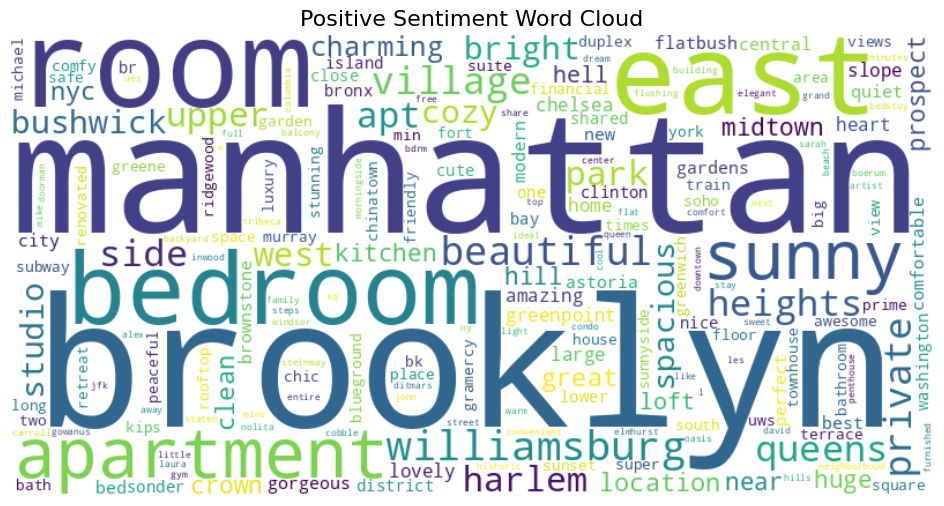

In [1]:
# Install and import libraries
import pandas as pd
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

# Download required NLTK resources
nltk.download('vader_lexicon')
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')

# Load dataset from the Colab environment
from google.colab import files
uploaded = files.upload()
df = pd.read_csv("AB_NYC_2019.csv")

# Prepare text fields for analysis
df = df[['name','host_name','neighbourhood','neighbourhood_group']].fillna("")
df['combined_text'] = df.apply(lambda x: ' '.join(x), axis=1)

# Sentiment scoring
sia = SentimentIntensityAnalyzer()
df['compound'] = df['combined_text'].apply(lambda x: sia.polarity_scores(x)['compound'])

# Filter for positive sentiment rows
positive_texts = df[df['compound'] > 0]['combined_text']

# Tokenize and clean words for positive sentiment
stop_words = set(stopwords.words('english'))
positive_words = []
for text in positive_texts:
    tokens = word_tokenize(text.lower())

# Keep only alphabetic tokens and remove stopwords
    filtered = [tok for tok in tokens if tok.isalpha() and tok not in stop_words]
    positive_words.extend(filtered)

# Produce a frequency ranking
positive_word_freq = pd.Series(positive_words).value_counts()

# Display top 30 words associated with positive sentiment
print("Top 30 words associated with positive sentiment:")
print(positive_word_freq.head(30))

# Install wordcloud
!pip install wordcloud

# Import visualization libraries
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# Generate word cloud from frequency data
wordcloud = WordCloud(width=800, height=400,
                      background_color='white',
                      colormap='viridis',
                      max_words=200).generate_from_frequencies(positive_word_freq)

# Display the word cloud results
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Positive Sentiment Word Cloud", fontsize=16)